In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use("paper.mplstyle")

Peak frequency: 3.000 Hz
Peak width (FWHM): 0.250 Hz
Width at 1/10 maximum (WFHM): 0.250 Hz


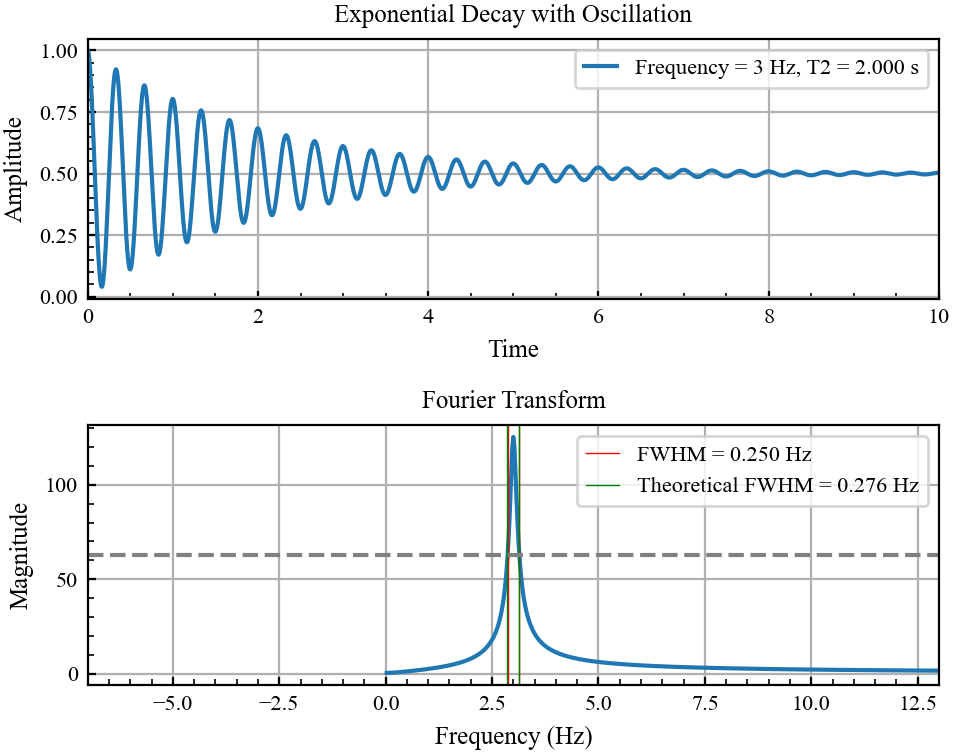

In [2]:
# Generate time data

T2 = 2  # Decay time constant
t = np.linspace(0, T2*20, 10000)
theoretical_T2_limit = np.sqrt(3)/T2/np.pi


zoom_in = 10
# Create exponential decay with oscillation
decay_rate = 1/T2
frequency = 3
signal = 0.5*np.exp(-decay_rate * t) * np.cos(2 * np.pi * frequency * t)+0.5


# Calculate Fourier transform
fft = np.fft.fft(signal)
fft_freq = np.fft.fftfreq(len(t), t[1] - t[0])

# Only keep positive frequencies
positive_freq_idx = fft_freq > 0
fft_freq_pos = fft_freq[positive_freq_idx]
fft_magnitude = np.abs(fft[positive_freq_idx])

# Calculate peak width (FWHM - Full Width at Half Maximum)
peak_idx = np.argmax(fft_magnitude)
peak_value = fft_magnitude[peak_idx]
half_max = peak_value / 2

# Find indices where magnitude is above half maximum
above_half = fft_magnitude > half_max
indices_above = np.where(above_half)[0]
peak_width = fft_freq_pos[indices_above[-1]] - fft_freq_pos[indices_above[0]]

# Create subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(5, 4))

# Top plot: Exponential decay with oscillation
ax1.plot(t, signal, label=f'Frequency = {frequency} Hz, T2 = {T2:.3f} s')
ax1.set_xlim(0, 10)
ax1.set_xlabel('Time')
ax1.set_ylabel('Amplitude')
ax1.set_title('Exponential Decay with Oscillation')
ax1.grid(True)

# Bottom plot: Fourier transform
ax2.plot(fft_freq_pos, fft_magnitude)
ax2.axhline(y=half_max, color='r', linestyle='--', label=f'FWHM = {peak_width:.3f} Hz')
ax2.set_xlabel('Frequency (Hz)')
ax2.set_ylabel('Magnitude')
ax2.set_title('Fourier Transform')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
# plt.show()

print(f"Peak frequency: {fft_freq_pos[peak_idx]:.3f} Hz")
print(f"Peak width (FWHM): {peak_width:.3f} Hz")

# Calculate WFHM (Width at Fraction of Half Maximum, typically 1/10th)
# This gives a broader measure of the peak width
fraction = 0.5  # 1/10th of maximum
fractional_max = peak_value * fraction

# Find indices where magnitude is above fractional maximum
above_fractional = fft_magnitude > fractional_max
indices_above_fractional = np.where(above_fractional)[0]
wfhm = fft_freq_pos[indices_above_fractional[-1]] - fft_freq_pos[indices_above_fractional[0]]

# Add WFHM line to the plot
ax2.axhline(y=fractional_max, color='g', linestyle='--', label=f'WFHM (1/10 max) = {wfhm:.3f} Hz')
ax2.legend()

ax2.clear()
ax2.plot(fft_freq_pos, fft_magnitude)
ax2.axvline(x=fft_freq_pos[indices_above[0]], color='r', linestyle='-', label=f'FWHM = {peak_width:.3f} Hz',linewidth=0.5)
ax2.axvline(x=fft_freq_pos[indices_above[-1]], color='r', linestyle='-',linewidth=0.5)
ax2.axvline(x=frequency+theoretical_T2_limit/2, color='g', linestyle='-', label=f'Theoretical FWHM = {theoretical_T2_limit:.3f} Hz',linewidth=0.5)
ax2.axvline(x=frequency-theoretical_T2_limit/2, color='g', linestyle='-',linewidth=0.5)
ax2.axhline(y=fractional_max, color='gray', linestyle='--')
ax2.set_xlabel('Frequency (Hz)')
ax2.set_ylabel('Magnitude')
ax2.set_title('Fourier Transform')
ax2.legend()
ax2.set_xlim(frequency-zoom_in, frequency+zoom_in)  # Zoom in around the peak
ax2.grid(True)
plt.tight_layout()

print(f"Width at 1/10 maximum (WFHM): {wfhm:.3f} Hz")

# Save the figure to a file (optional)
plt.savefig('fft_analysis.png', dpi=150, bbox_inches='tight')

# Add oscillation frequency and decay rate to the top plot legend
ax1.legend()
plt.draw()



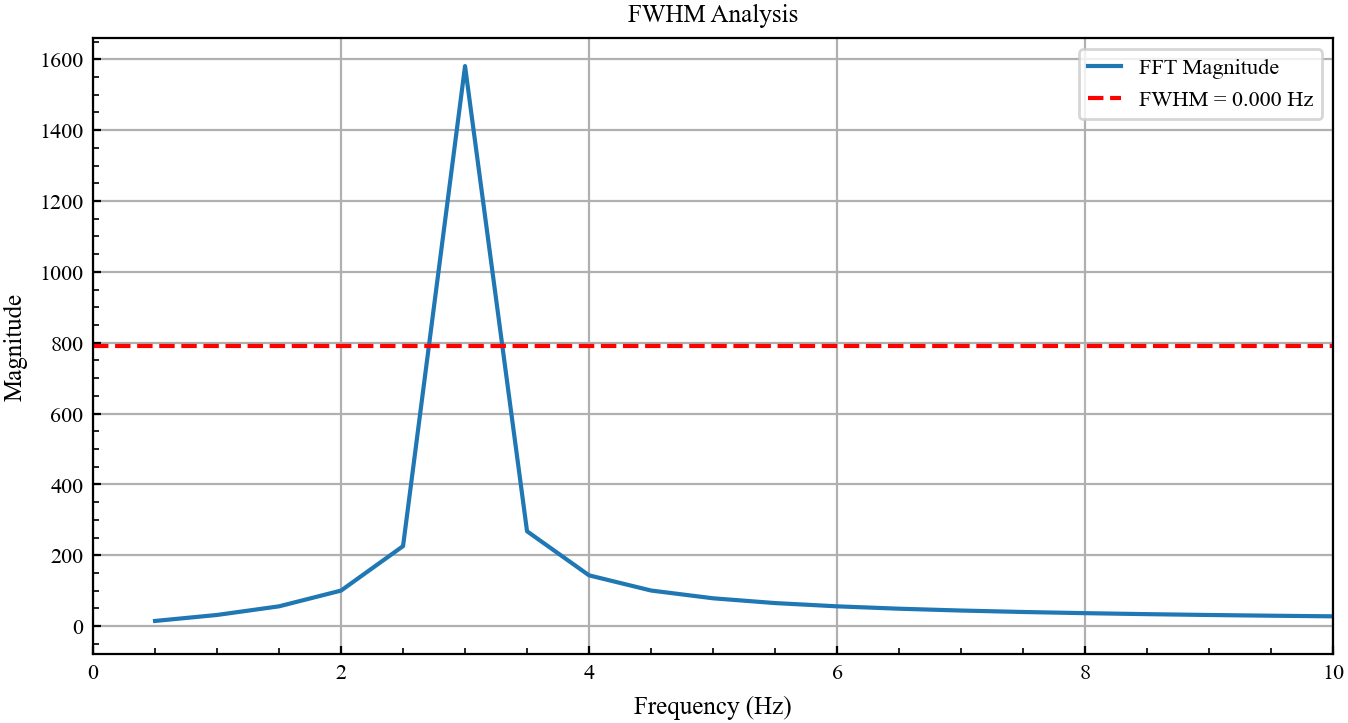

Calculated FWHM: 0.000 Hz


In [19]:



def fwhm_from_signal_time(signal, t, plot=False):
    """
    Calculate FWHM from signal in time domain.
    
    Parameters:
    -----------
    signal : array
        Time domain signal
    t : array
        Time values
    plot : bool
        If True, plot the Fourier transform with FWHM markers
    
    Returns:
    --------
    fwhm : float
        Full Width at Half Maximum in frequency domain
    """
    # Fourier transform
    fft_vals = np.fft.fft(signal)
    fft_freq = np.fft.fftfreq(len(t), t[1] - t[0])

    # Positive frequencies
    pos_mask = fft_freq > 0
    freq_pos = fft_freq[pos_mask]
    mag = np.abs(fft_vals[pos_mask])

    # FWHM
    peak_idx = np.argmax(mag)
    peak_val = mag[peak_idx]
    half_max = peak_val / 2

    above = mag > half_max
    idx = np.where(above)[0]
    fwhm = freq_pos[idx[-1]] - freq_pos[idx[0]]
    
    if plot:
        plt.figure(figsize=(8, 4))
        plt.plot(freq_pos, mag, label='FFT Magnitude')
        plt.axhline(y=half_max, color='r', linestyle='--', label=f'FWHM = {fwhm:.3f} Hz')
        # plt.axvline(x=freq_pos[idx[0]], color='r', linestyle='-', linewidth=0.5)
        # plt.axvline(x=freq_pos[idx[-1]], color='r', linestyle='-', linewidth=0.5)
        plt.xlim(0, 10)  # Zoom in around the peak
        plt.xlabel('Frequency (Hz)')
        plt.ylabel('Magnitude')
        plt.title('FWHM Analysis')
        plt.legend()
        plt.grid(True)
        plt.show()
    
    return fwhm


# Example usage
t_max = 1*T2
t = np.linspace(0, t_max, 10000)

signal = 0.5*np.exp(-decay_rate * t) * np.cos(2 * np.pi * frequency * t)+0.5



fwhm_result = fwhm_from_signal_time(signal, t, plot=True)
print(f"Calculated FWHM: {fwhm_result:.3f} Hz")

